## Sampling and empirical distribution




In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("united_summer2015.csv")
df

,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
...,...,...,...,...
13820,8/31/15,1978,LAS,-4
13821,8/31/15,1993,IAD,8
13822,8/31/15,1994,ORD,3
13823,8/31/15,2000,PHX,-1


In [3]:
df.describe()

,Flight Number,Delay
count,13825.000000,13825.000000
mean,1133.415045,16.658156
std,571.858597,39.481628
min,3.000000,-16.000000
25%,591.000000,-2.000000
50%,1178.000000,2.000000
75%,1670.000000,18.000000
max,2117.000000,580.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13825 entries, 0 to 13824
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           13825 non-null  object
 1   Flight Number  13825 non-null  int64 
 2   Destination    13825 non-null  object
 3   Delay          13825 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 432.2+ KB


<Axes: >

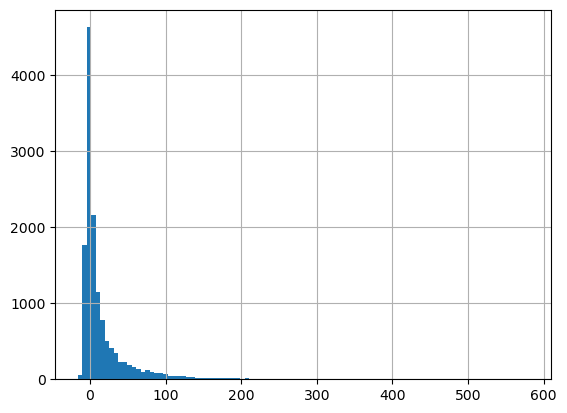

In [5]:
df["Delay"].hist(bins=100)

In [6]:
def empirical_hist_delay(n):
    df["Delay"].sample(n).hist(bins = 100)

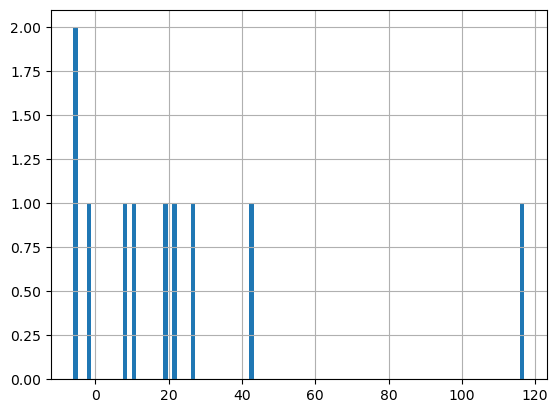

In [7]:
empirical_hist_delay(10)

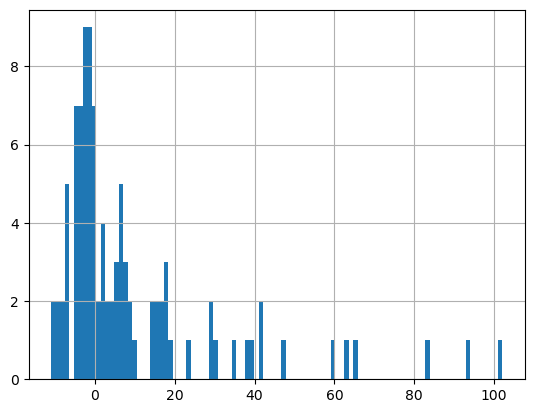

In [8]:
empirical_hist_delay(100)

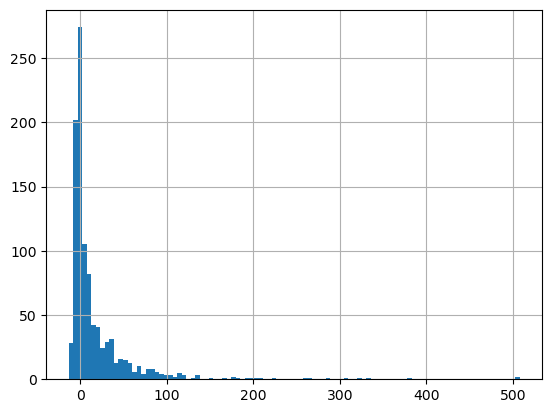

In [9]:
empirical_hist_delay(1000)

## Note the difference among the statistics obtained from different simulations:

In [10]:
df["Delay"].sample(1000).mean()

15.355

In [11]:
df["Delay"].sample(1000).mean()

16.212

In [12]:
df["Delay"].sample(1000).mean()

14.527

## How to get a closer estimate? 
## Simulate the statistic for sufficiently big number of times:


In [20]:
mean_population = []
for i in range(5000):
    sampled_mean = df["Delay"].sample(1000).median() 
    mean_population.append(sampled_mean)

In [21]:
mean_df = pd.DataFrame(mean_population, columns=["Mean"])
mean_df

,Mean
0,2.0
1,2.0
2,3.0
3,3.0
4,3.0
...,...
4995,2.0
4996,3.0
4997,3.0
4998,3.0


array([[<Axes: title={'center': 'Mean'}>]], dtype=object)

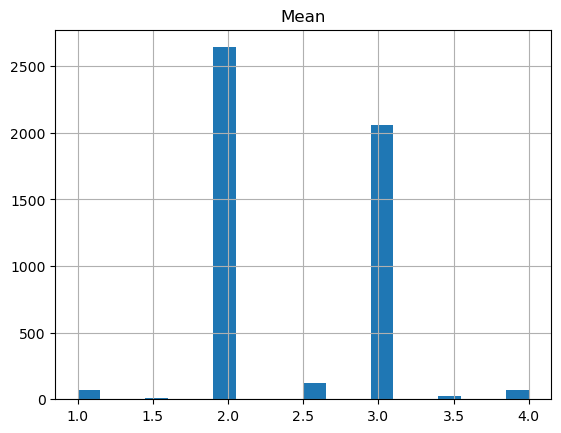

In [22]:
mean_df.hist(bins=20)

Using replace=True:

In [16]:
mean_population = []
for i in range(5000):
    sampled_mean = df["Delay"].sample(1000,replace=True).mean() 
    mean_population.append(sampled_mean)

In [17]:
mean_df = pd.DataFrame(mean_population, columns=["Mean"])
mean_df

,Mean
0,17.145
1,17.529
2,17.084
3,14.468
4,17.631
...,...
4995,17.026
4996,15.321
4997,16.271
4998,18.280


array([[<Axes: title={'center': 'Mean'}>]], dtype=object)

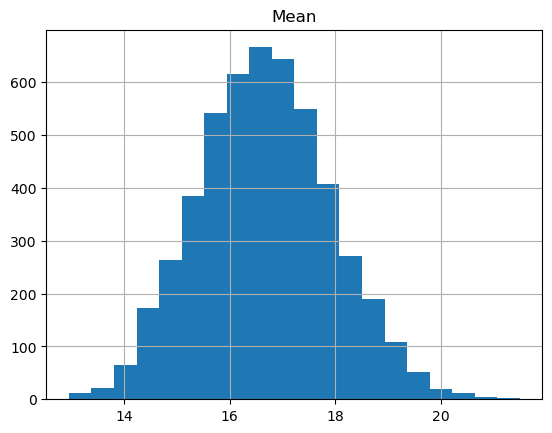

In [18]:
mean_df.hist(bins=20)

In [19]:
## note any difference between with and without replacement? No indeed. That has a significance!